In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)


PyTorch version: 2.10.0+cpu


In [4]:
# Load and prepare — same pipeline
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
df['FarePerPerson'] = df['Fare'] / df['FamilySize']
df = df.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId'])
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

X = df.drop(columns=['Survived']).values.astype(np.float32)
y = df['Survived'].values.astype(np.float32)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(1)

print("X_train shape:", X_train_t.shape)
print("y_train shape:", y_train_t.shape)

X_train shape: torch.Size([712, 11])
y_train shape: torch.Size([712, 1])


In [5]:
class TitanicNet(nn.Module):
    def __init__(self, input_size):
        super(TitanicNet, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

# Reinitialize everything fresh
input_size = X_train_t.shape[1]
model = TitanicNet(input_size)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")

TitanicNet(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=16, out_features=1, bias=True)
    (10): Sigmoid()
  )
)
Total parameters: 3393


In [6]:
criterion = nn.BCELoss()                           # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [7]:
def train_model(model, X_train, y_train, X_test, y_test, 
                criterion, optimizer, epochs=200):
    
    train_losses = []
    test_losses  = []
    train_accs   = []
    test_accs    = []
    
    for epoch in range(epochs):
        # ── Training phase ──
        model.train()                          # set model to training mode
        optimizer.zero_grad()                  # clear gradients from last step
        
        y_pred = model(X_train)                # forward pass
        loss = criterion(y_pred, y_train)      # calculate loss
        loss.backward()                        # backward pass — compute gradients
        optimizer.step()                       # update weights
        
        # ── Evaluation phase ──
        model.eval()                           # set model to evaluation mode
        with torch.no_grad():                  # don't track gradients during eval
            y_pred_test = model(X_test)
            test_loss = criterion(y_pred_test, y_test)
        
        # ── Record metrics ──
        train_losses.append(loss.item())
        test_losses.append(test_loss.item())
        
        # Convert probabilities to 0/1 predictions
        train_preds = (y_pred > 0.5).float()
        test_preds  = (y_pred_test > 0.5).float()
        
        train_acc = (train_preds == y_train).float().mean().item()
        test_acc  = (test_preds  == y_test).float().mean().item()
        
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {loss.item():.4f} | "
                  f"Test Loss: {test_loss.item():.4f} | "
                  f"Train Acc: {train_acc:.4f} | "
                  f"Test Acc: {test_acc:.4f}")
    
    return train_losses, test_losses, train_accs, test_accs

# Train
train_losses, test_losses, train_accs, test_accs = train_model(
    model, X_train_t, y_train_t, X_test_t, y_test_t,
    criterion, optimizer, epochs=200
)

Epoch  10/200 | Train Loss: 0.6721 | Test Loss: 0.6722 | Train Acc: 0.6348 | Test Acc: 0.6257
Epoch  20/200 | Train Loss: 0.6591 | Test Loss: 0.6583 | Train Acc: 0.6728 | Test Acc: 0.6536
Epoch  30/200 | Train Loss: 0.6326 | Test Loss: 0.6320 | Train Acc: 0.7093 | Test Acc: 0.6816
Epoch  40/200 | Train Loss: 0.5915 | Test Loss: 0.5843 | Train Acc: 0.7331 | Test Acc: 0.7318
Epoch  50/200 | Train Loss: 0.5328 | Test Loss: 0.5251 | Train Acc: 0.7781 | Test Acc: 0.7709
Epoch  60/200 | Train Loss: 0.4880 | Test Loss: 0.4787 | Train Acc: 0.7837 | Test Acc: 0.7654
Epoch  70/200 | Train Loss: 0.4627 | Test Loss: 0.4555 | Train Acc: 0.8146 | Test Acc: 0.8156
Epoch  80/200 | Train Loss: 0.4546 | Test Loss: 0.4408 | Train Acc: 0.8048 | Test Acc: 0.8156
Epoch  90/200 | Train Loss: 0.4584 | Test Loss: 0.4349 | Train Acc: 0.8006 | Test Acc: 0.8101
Epoch 100/200 | Train Loss: 0.4358 | Test Loss: 0.4364 | Train Acc: 0.8118 | Test Acc: 0.8045
Epoch 110/200 | Train Loss: 0.4466 | Test Loss: 0.4384 | Tra

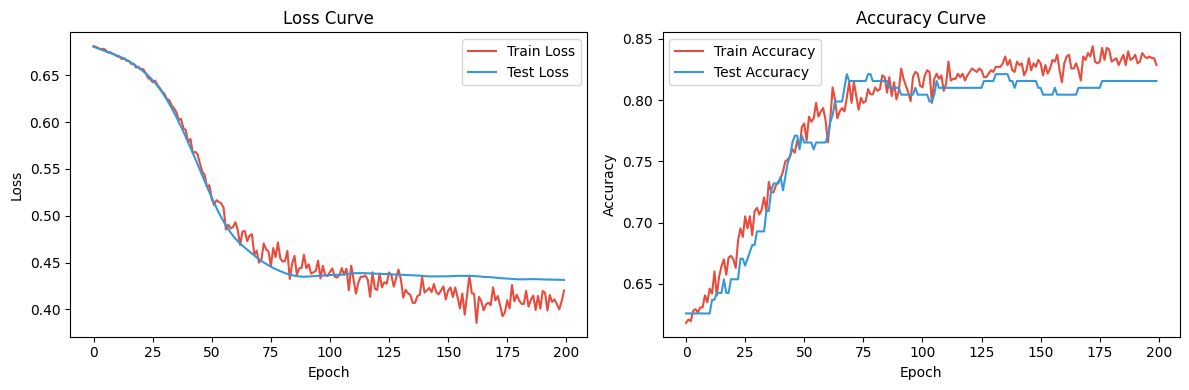

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
axes[0].plot(train_losses, label='Train Loss', color='#e74c3c')
axes[0].plot(test_losses,  label='Test Loss',  color='#3498db')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy curves
axes[1].plot(train_accs, label='Train Accuracy', color='#e74c3c')
axes[1].plot(test_accs,  label='Test Accuracy',  color='#3498db')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()
